# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [16]:
start_time = None
end_time = None
elapsed = None

with open("run.log") as f:
    for line in f:
        line = line.strip()

        if line.startswith("START:"):
            start_time = line.replace("START:", "").strip()

        elif line.startswith("END:"):
            end_time = line.replace("END:", "").strip()

        elif line.startswith("Total run time"):
            elapsed = line.replace("Total run time", "").strip()

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time}")
print(f"End Time   : {end_time}")
print(f"Run Time   : {elapsed}")

Simulation Information
----------------------
Start Time : None
End Time   : None
Run Time   : 10187.59369 seconds


# 使用者設定

In [17]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -6.250e+09
  BETA = 1.000e+11
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 7.000e-09 m


## Utils

In [18]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [19]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00005689
   plt00006200
   plt00007557
   plt00008655
   plt00009832
   plt00011912
   plt00013904
   plt00017618
   plt00019119
   plt00021982
   plt00023054
   plt00024661
   plt00025172
   plt00026485
   plt00027919
   plt00028357
   plt00029575
   plt00030520
   plt00031624
   plt00032099
   plt00033475
   plt00033987
   plt00035551
   plt00036822
   plt00038532
   plt00039455
   plt00043354
   plt00044579
   plt00045356
   plt00047924
   plt00049357
   plt00051046
   plt00052367
   plt00052814
   plt00054183
   plt00055026
   plt00056173
   plt00056634
   plt00058453
   plt00058931
   plt00060644
   plt00062022
   plt00064293
   plt00065100
   plt00068009
   plt00069499
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [20]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-07-08 16:59:17,495 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-07-08 16:59:17,496 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:17,496 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:17,496 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_withi

### 用key word查看dir(ds)中可能會用到的attribute

In [21]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [22]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [23]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [24]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [25]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotate_func__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__static_attributes__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_s

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [26]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.85e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.425e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.85e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [27]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-07-08 16:59:17,921 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-07-08 16:59:17,921 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:17,921 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:17,921 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


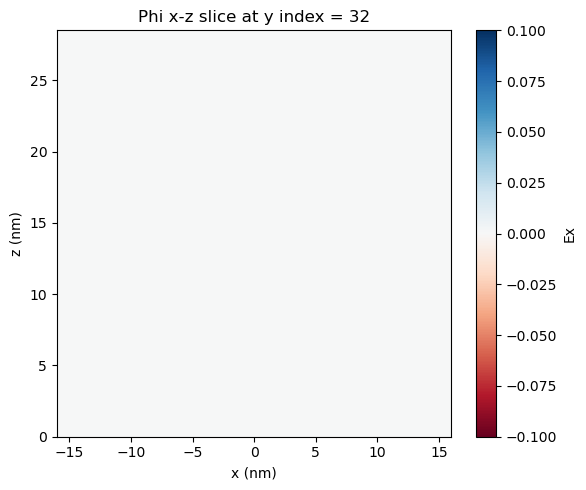

yt : [INFO     ] 2026-07-08 16:59:18,025 Parameters: current_time              = 1.1377999999999817e-09
yt : [INFO     ] 2026-07-08 16:59:18,026 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,026 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,026 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


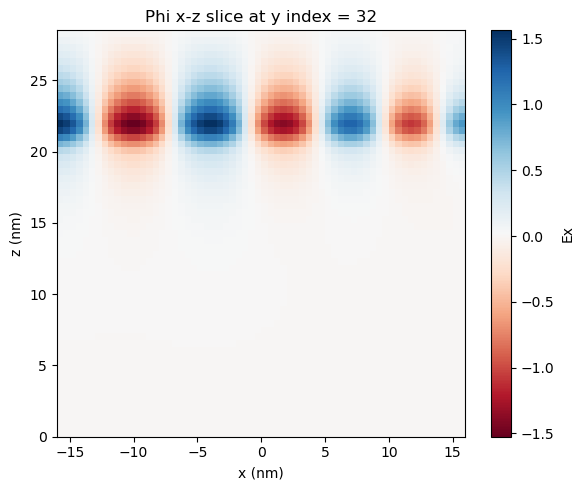

yt : [INFO     ] 2026-07-08 16:59:18,129 Parameters: current_time              = 1.240000000000013e-09
yt : [INFO     ] 2026-07-08 16:59:18,129 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,130 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,130 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


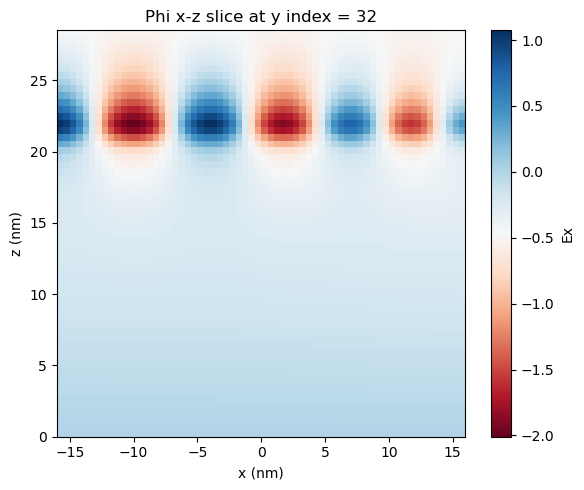

yt : [INFO     ] 2026-07-08 16:59:18,366 Parameters: current_time              = 1.5114000000000963e-09
yt : [INFO     ] 2026-07-08 16:59:18,366 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,366 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,366 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


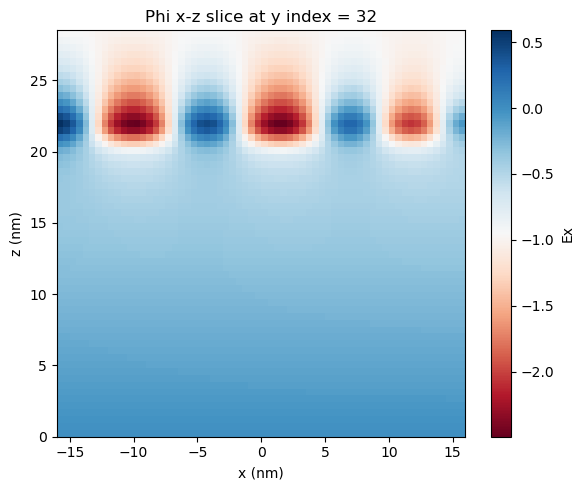

yt : [INFO     ] 2026-07-08 16:59:18,457 Parameters: current_time              = 1.7310000000001637e-09
yt : [INFO     ] 2026-07-08 16:59:18,457 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,457 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,457 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


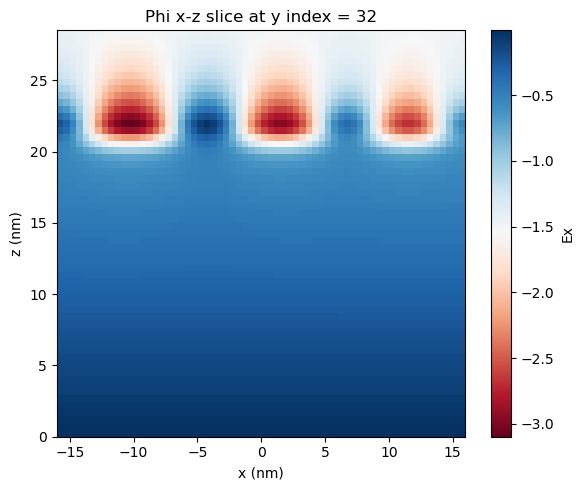

yt : [INFO     ] 2026-07-08 16:59:18,549 Parameters: current_time              = 1.966400000000236e-09
yt : [INFO     ] 2026-07-08 16:59:18,549 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,549 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,549 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


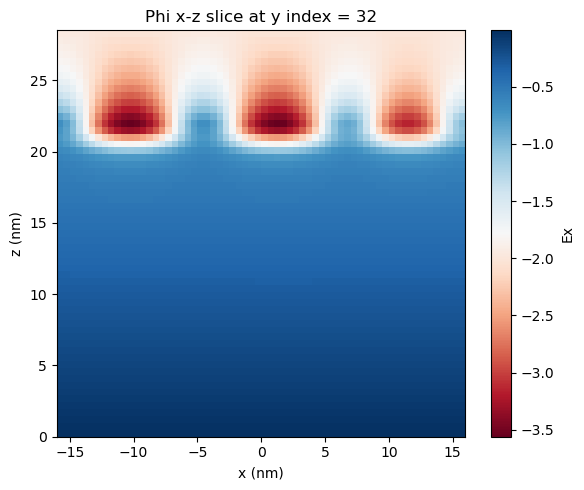

yt : [INFO     ] 2026-07-08 16:59:18,641 Parameters: current_time              = 2.3824000000003635e-09
yt : [INFO     ] 2026-07-08 16:59:18,641 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,641 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,641 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


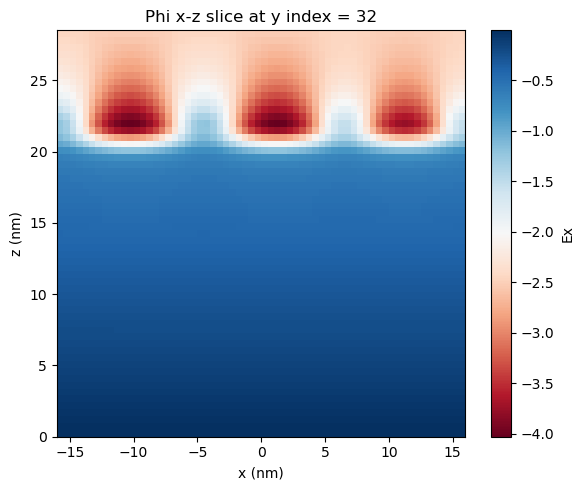

yt : [INFO     ] 2026-07-08 16:59:18,734 Parameters: current_time              = 2.7808000000004857e-09
yt : [INFO     ] 2026-07-08 16:59:18,734 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,734 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,734 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


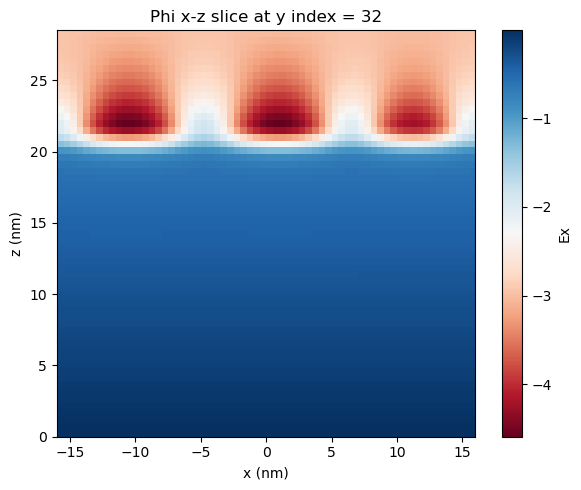

yt : [INFO     ] 2026-07-08 16:59:18,823 Parameters: current_time              = 3.5236000000007136e-09
yt : [INFO     ] 2026-07-08 16:59:18,824 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,824 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,824 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


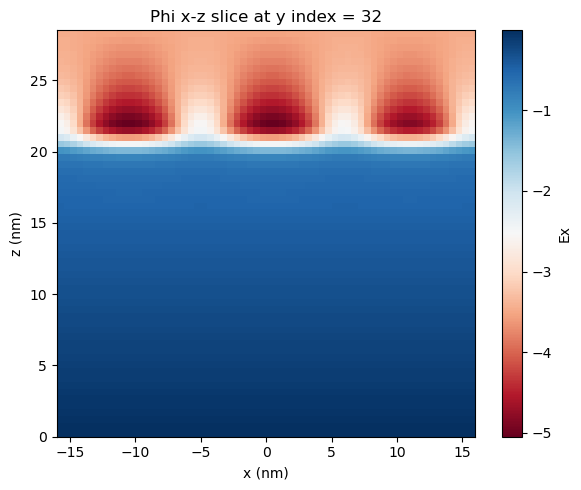

yt : [INFO     ] 2026-07-08 16:59:18,912 Parameters: current_time              = 3.823800000000806e-09
yt : [INFO     ] 2026-07-08 16:59:18,913 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:18,913 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:18,913 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


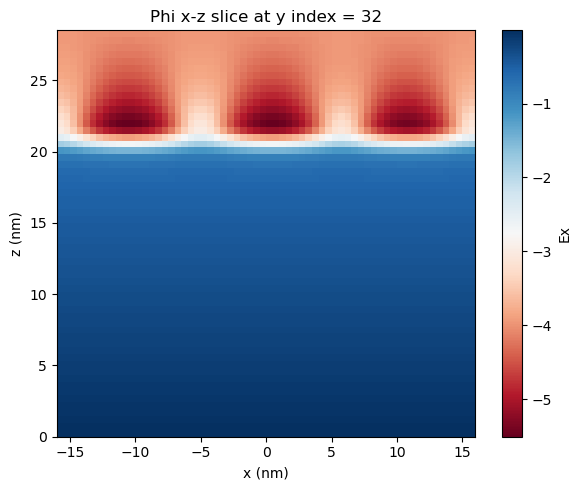

yt : [INFO     ] 2026-07-08 16:59:19,002 Parameters: current_time              = 4.396400000000981e-09
yt : [INFO     ] 2026-07-08 16:59:19,002 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,003 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,003 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


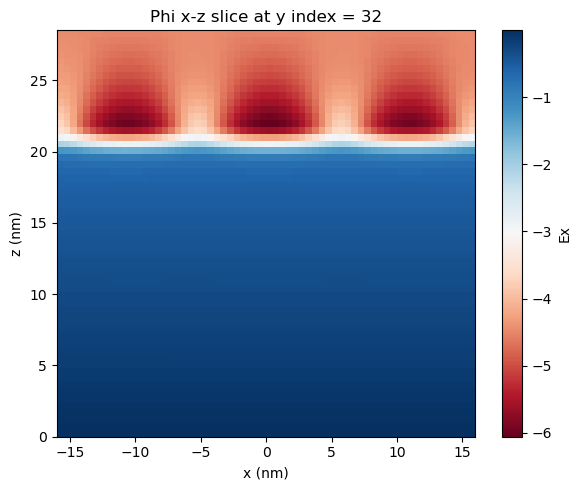

yt : [INFO     ] 2026-07-08 16:59:19,093 Parameters: current_time              = 4.610800000001047e-09
yt : [INFO     ] 2026-07-08 16:59:19,093 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,093 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,093 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


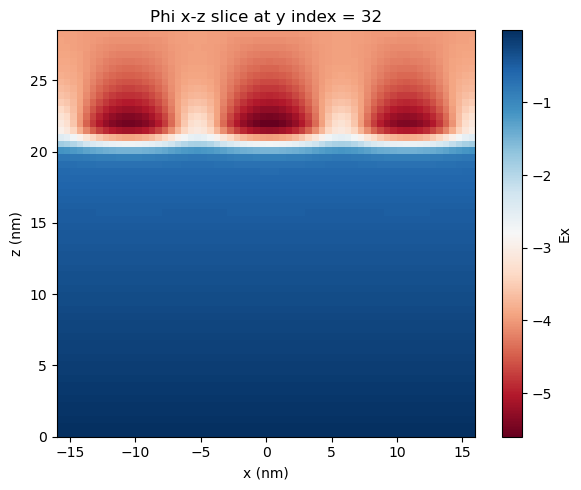

yt : [INFO     ] 2026-07-08 16:59:19,182 Parameters: current_time              = 4.932200000001146e-09
yt : [INFO     ] 2026-07-08 16:59:19,182 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,182 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,183 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


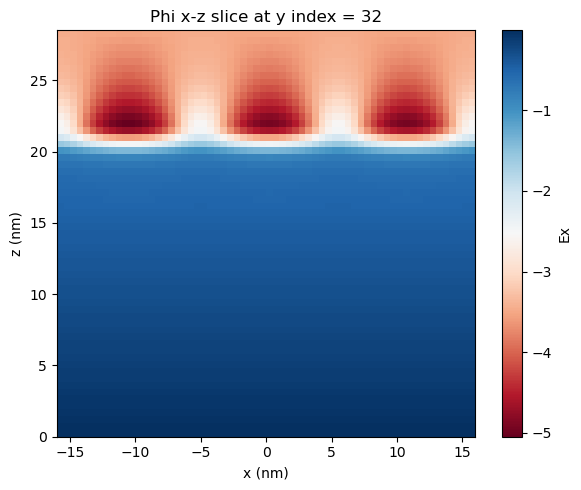

yt : [INFO     ] 2026-07-08 16:59:19,271 Parameters: current_time              = 5.034400000001177e-09
yt : [INFO     ] 2026-07-08 16:59:19,271 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,271 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,271 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


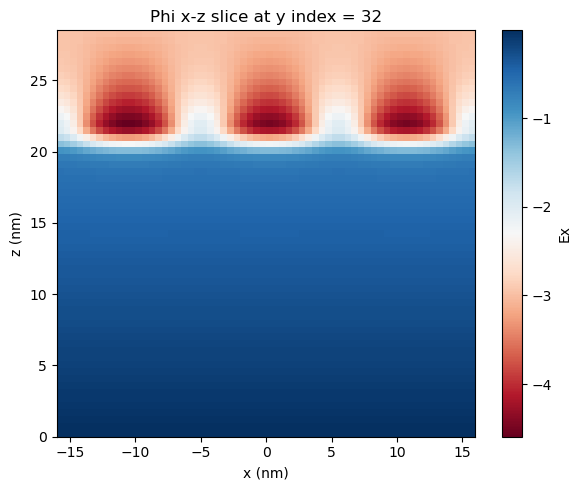

yt : [INFO     ] 2026-07-08 16:59:19,360 Parameters: current_time              = 5.2970000000012575e-09
yt : [INFO     ] 2026-07-08 16:59:19,360 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,360 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,360 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


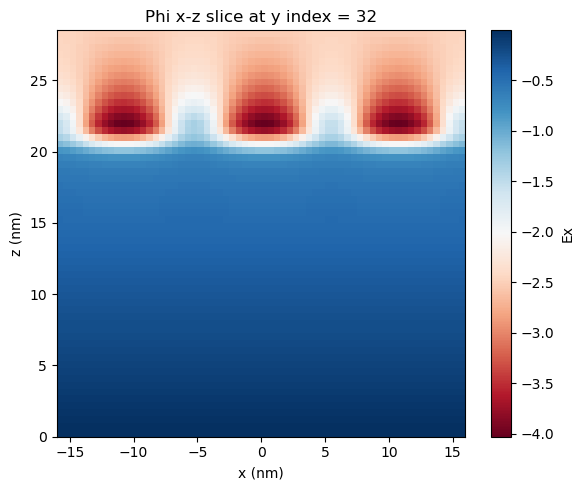

yt : [INFO     ] 2026-07-08 16:59:19,595 Parameters: current_time              = 5.5838000000013455e-09
yt : [INFO     ] 2026-07-08 16:59:19,595 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,595 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,596 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


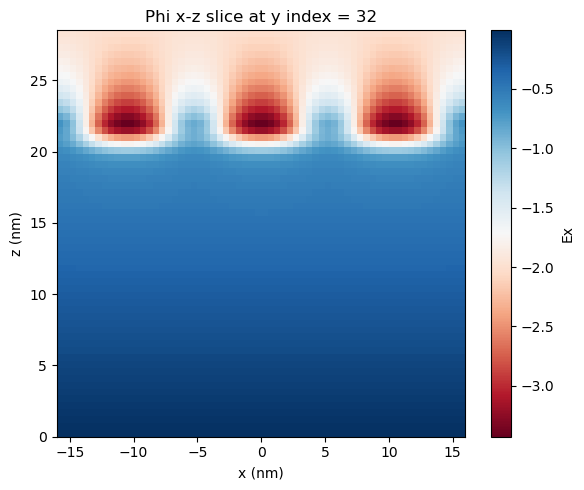

yt : [INFO     ] 2026-07-08 16:59:19,686 Parameters: current_time              = 5.671400000001372e-09
yt : [INFO     ] 2026-07-08 16:59:19,687 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,687 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,687 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


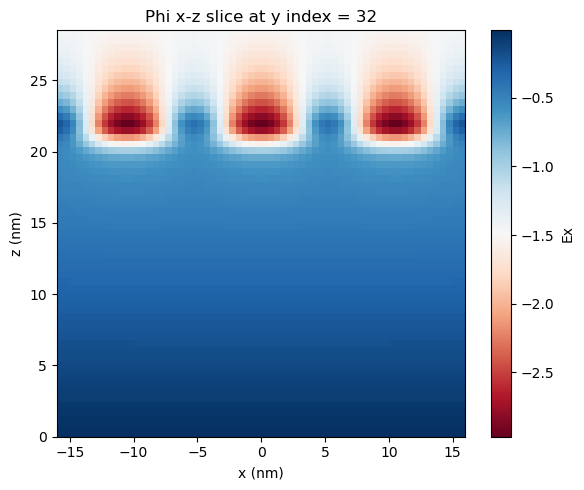

yt : [INFO     ] 2026-07-08 16:59:19,776 Parameters: current_time              = 5.915000000001447e-09
yt : [INFO     ] 2026-07-08 16:59:19,776 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,776 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,776 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


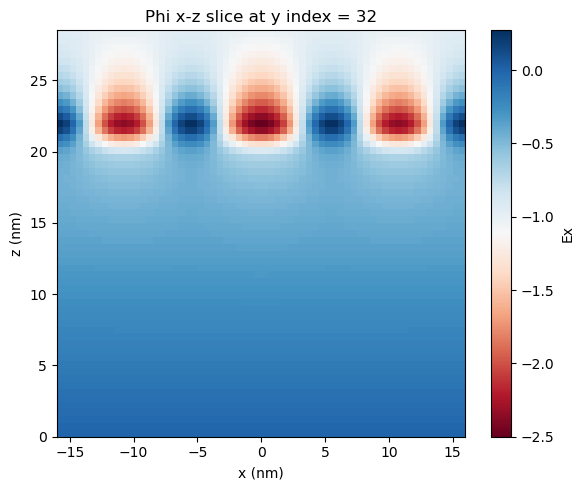

yt : [INFO     ] 2026-07-08 16:59:19,867 Parameters: current_time              = 6.104000000001505e-09
yt : [INFO     ] 2026-07-08 16:59:19,867 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,868 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,868 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


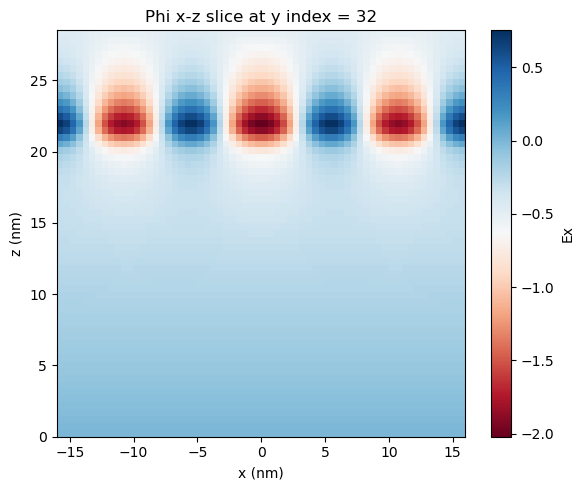

yt : [INFO     ] 2026-07-08 16:59:19,960 Parameters: current_time              = 6.324800000001573e-09
yt : [INFO     ] 2026-07-08 16:59:19,960 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:19,960 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:19,960 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


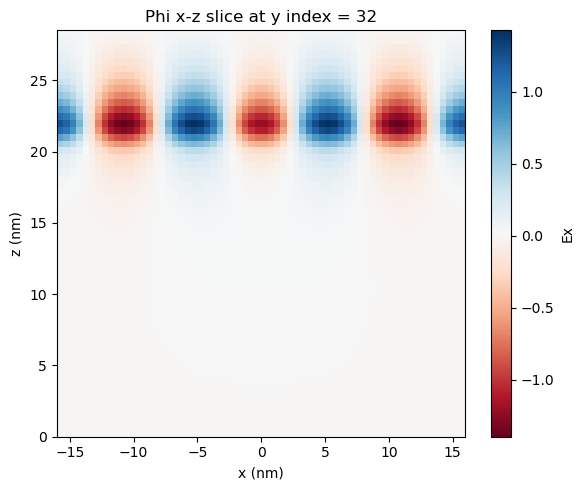

yt : [INFO     ] 2026-07-08 16:59:20,051 Parameters: current_time              = 6.419800000001602e-09
yt : [INFO     ] 2026-07-08 16:59:20,051 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,051 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,051 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


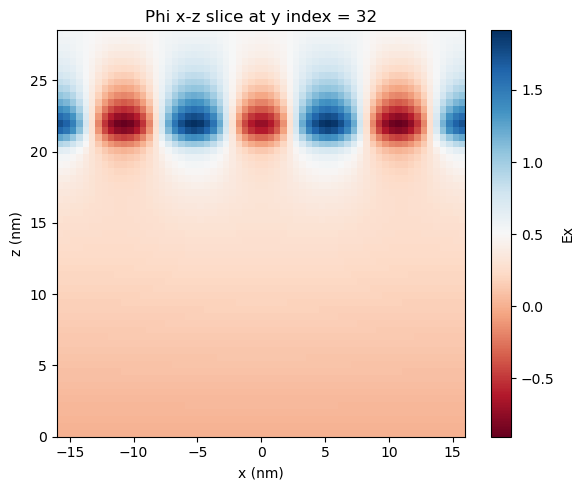

yt : [INFO     ] 2026-07-08 16:59:20,141 Parameters: current_time              = 6.695000000001686e-09
yt : [INFO     ] 2026-07-08 16:59:20,141 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,141 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,142 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


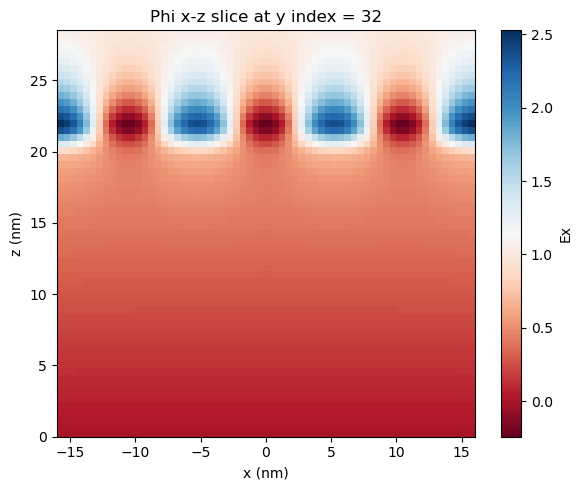

yt : [INFO     ] 2026-07-08 16:59:20,232 Parameters: current_time              = 6.797400000001718e-09
yt : [INFO     ] 2026-07-08 16:59:20,232 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,233 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,233 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


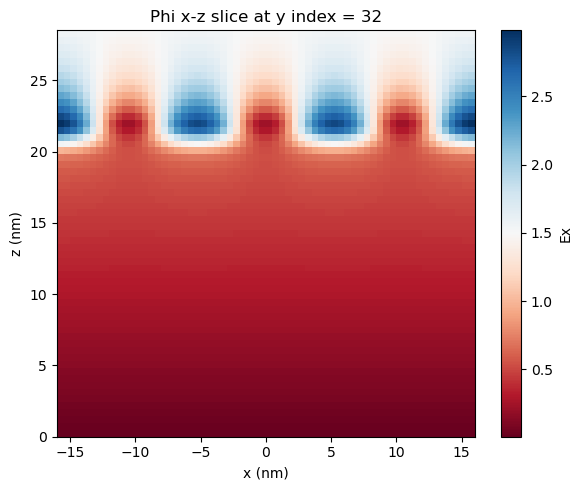

yt : [INFO     ] 2026-07-08 16:59:20,323 Parameters: current_time              = 7.110200000001814e-09
yt : [INFO     ] 2026-07-08 16:59:20,323 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,323 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,323 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


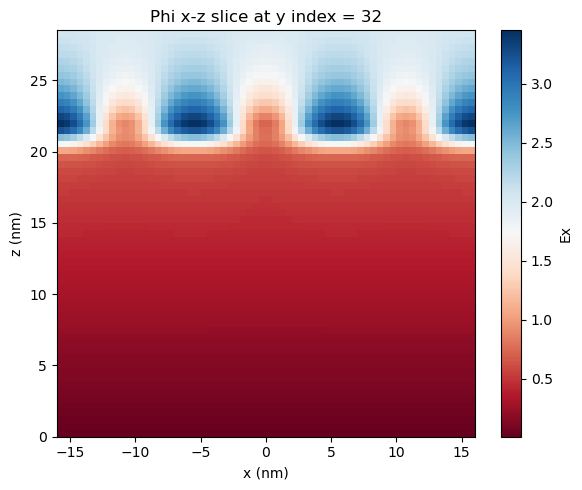

yt : [INFO     ] 2026-07-08 16:59:20,413 Parameters: current_time              = 7.364400000001892e-09
yt : [INFO     ] 2026-07-08 16:59:20,413 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,414 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,414 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


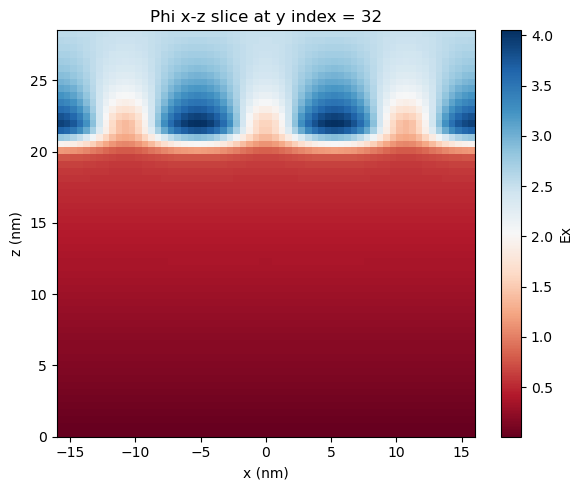

yt : [INFO     ] 2026-07-08 16:59:20,506 Parameters: current_time              = 7.706400000000938e-09
yt : [INFO     ] 2026-07-08 16:59:20,506 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,506 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,507 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


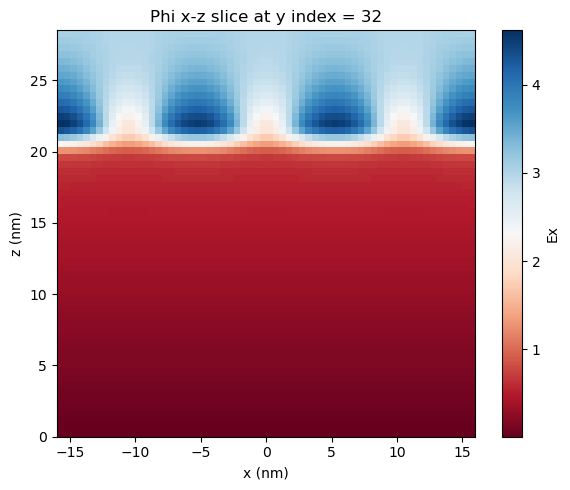

yt : [INFO     ] 2026-07-08 16:59:20,594 Parameters: current_time              = 7.891000000000231e-09
yt : [INFO     ] 2026-07-08 16:59:20,594 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,594 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,594 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


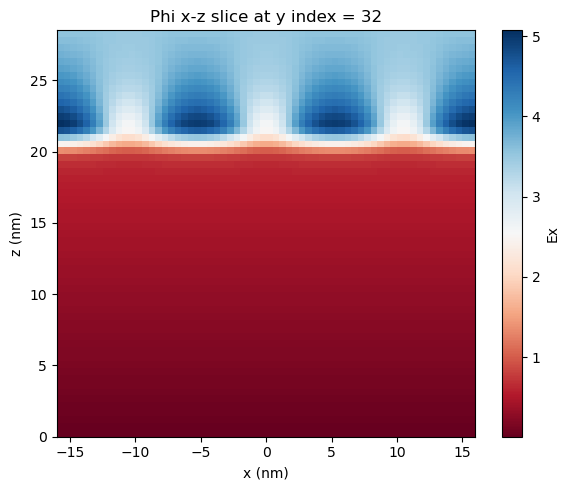

yt : [INFO     ] 2026-07-08 16:59:20,683 Parameters: current_time              = 8.670799999997245e-09
yt : [INFO     ] 2026-07-08 16:59:20,683 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,683 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,683 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


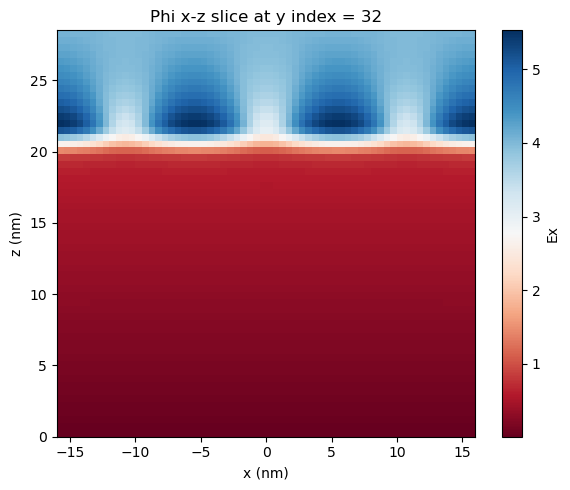

yt : [INFO     ] 2026-07-08 16:59:20,918 Parameters: current_time              = 8.915799999996307e-09
yt : [INFO     ] 2026-07-08 16:59:20,918 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:20,918 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:20,919 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


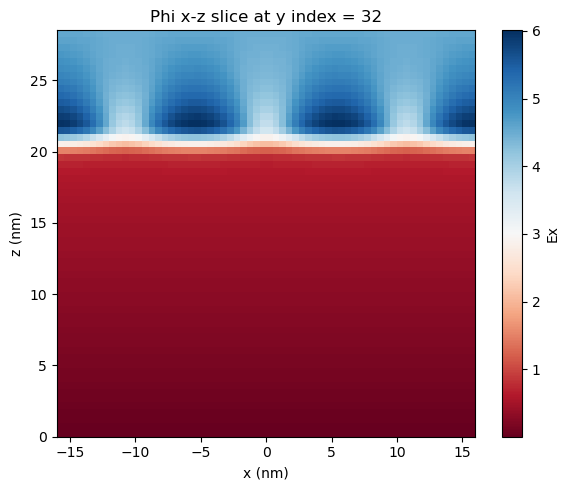

yt : [INFO     ] 2026-07-08 16:59:21,009 Parameters: current_time              = 9.071199999995712e-09
yt : [INFO     ] 2026-07-08 16:59:21,009 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,009 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,009 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


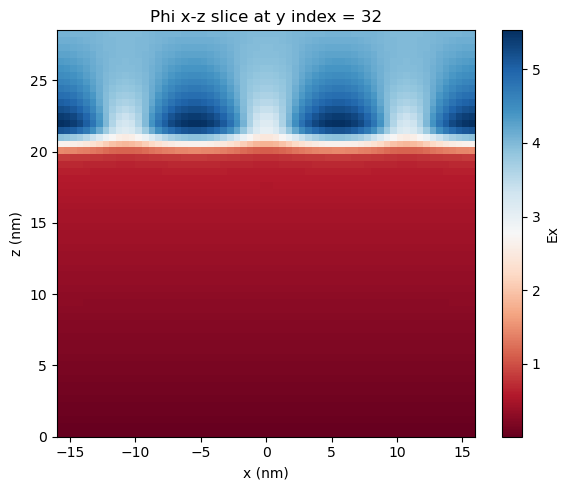

yt : [INFO     ] 2026-07-08 16:59:21,098 Parameters: current_time              = 9.584799999993745e-09
yt : [INFO     ] 2026-07-08 16:59:21,099 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,099 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,099 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


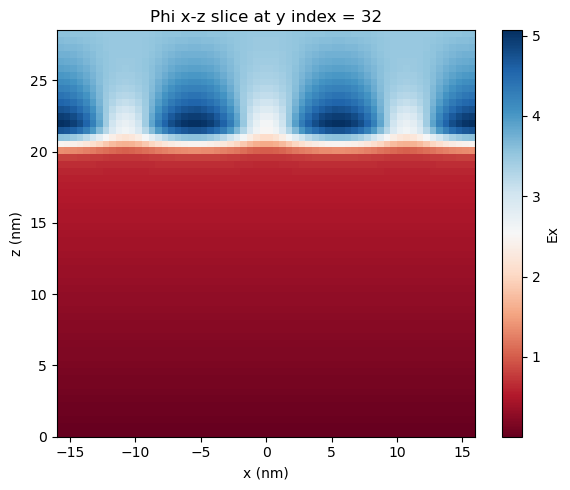

yt : [INFO     ] 2026-07-08 16:59:21,190 Parameters: current_time              = 9.871399999992648e-09
yt : [INFO     ] 2026-07-08 16:59:21,190 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,190 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,191 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


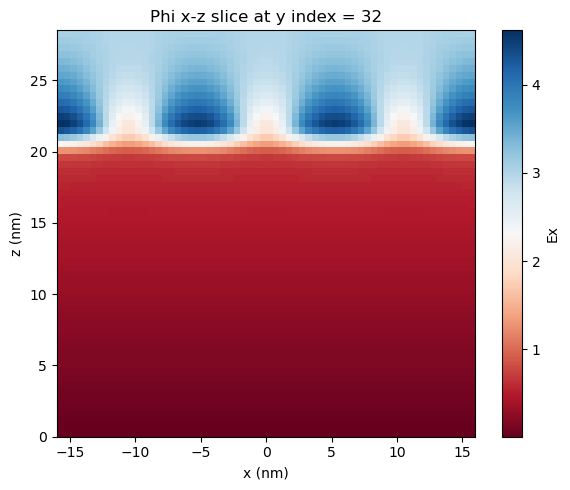

yt : [INFO     ] 2026-07-08 16:59:21,288 Parameters: current_time              = 1.0209199999991354e-08
yt : [INFO     ] 2026-07-08 16:59:21,288 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,289 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,289 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


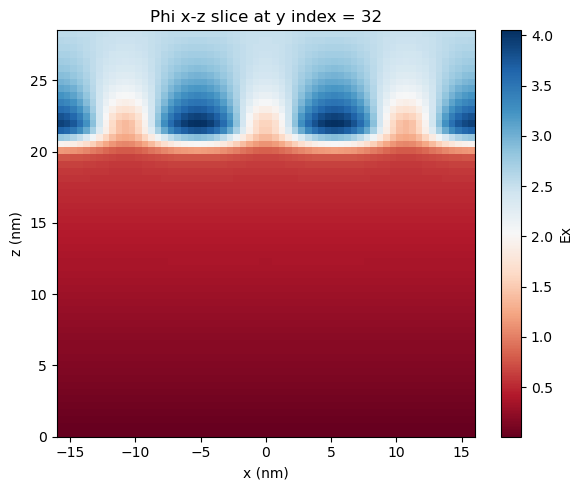

yt : [INFO     ] 2026-07-08 16:59:21,388 Parameters: current_time              = 1.0473399999990343e-08
yt : [INFO     ] 2026-07-08 16:59:21,389 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,389 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,389 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


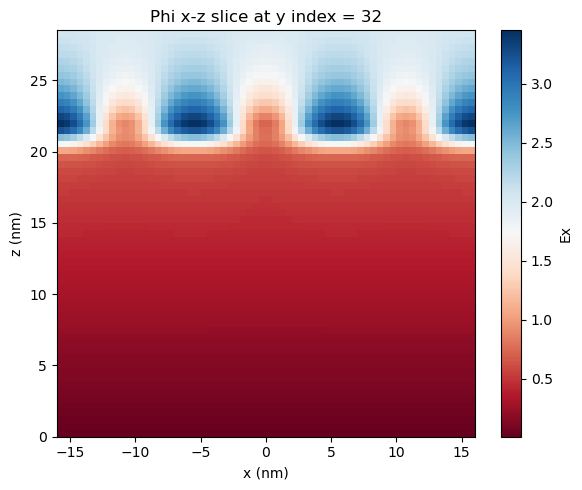

yt : [INFO     ] 2026-07-08 16:59:21,482 Parameters: current_time              = 1.056279999999e-08
yt : [INFO     ] 2026-07-08 16:59:21,482 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,482 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,482 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


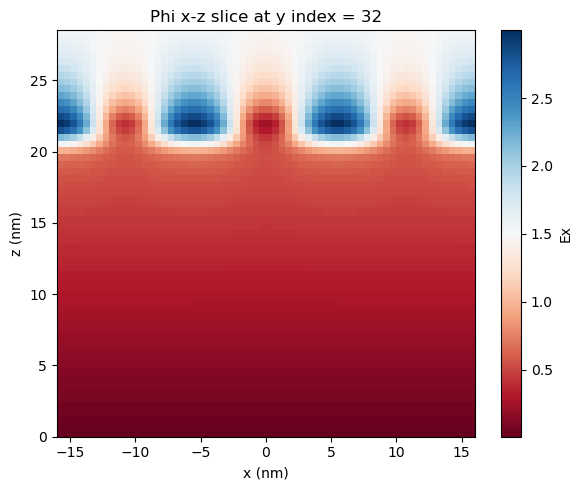

yt : [INFO     ] 2026-07-08 16:59:21,572 Parameters: current_time              = 1.0836599999988952e-08
yt : [INFO     ] 2026-07-08 16:59:21,572 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,572 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,572 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


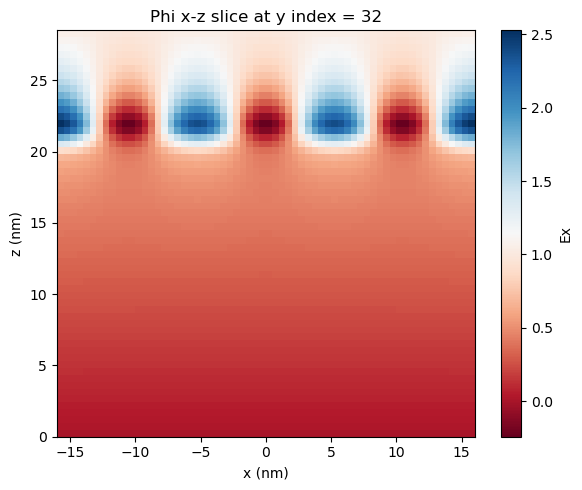

yt : [INFO     ] 2026-07-08 16:59:21,665 Parameters: current_time              = 1.1005199999988306e-08
yt : [INFO     ] 2026-07-08 16:59:21,665 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,665 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,665 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


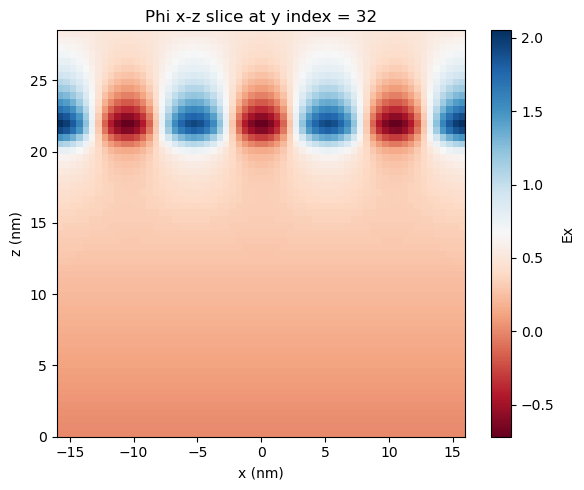

yt : [INFO     ] 2026-07-08 16:59:21,756 Parameters: current_time              = 1.1234599999987428e-08
yt : [INFO     ] 2026-07-08 16:59:21,756 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,756 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,756 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


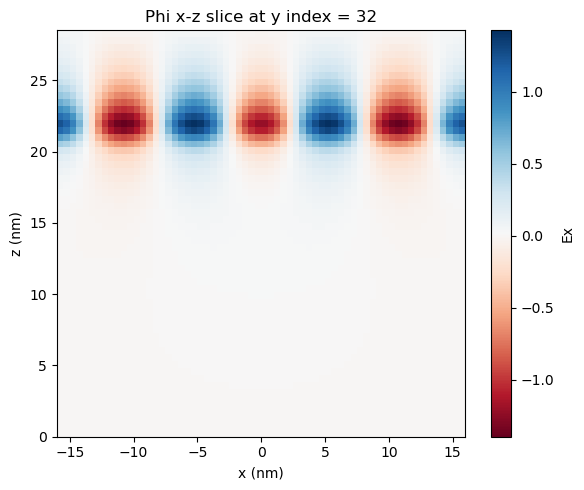

yt : [INFO     ] 2026-07-08 16:59:21,846 Parameters: current_time              = 1.1326799999987075e-08
yt : [INFO     ] 2026-07-08 16:59:21,846 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,846 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,846 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


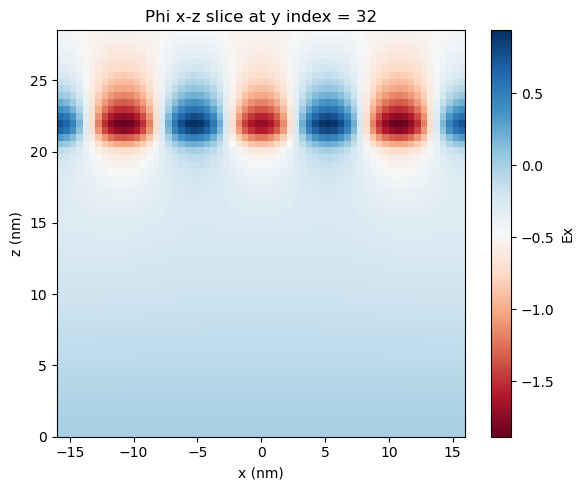

yt : [INFO     ] 2026-07-08 16:59:21,937 Parameters: current_time              = 1.1690599999985682e-08
yt : [INFO     ] 2026-07-08 16:59:21,937 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:21,937 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:21,937 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


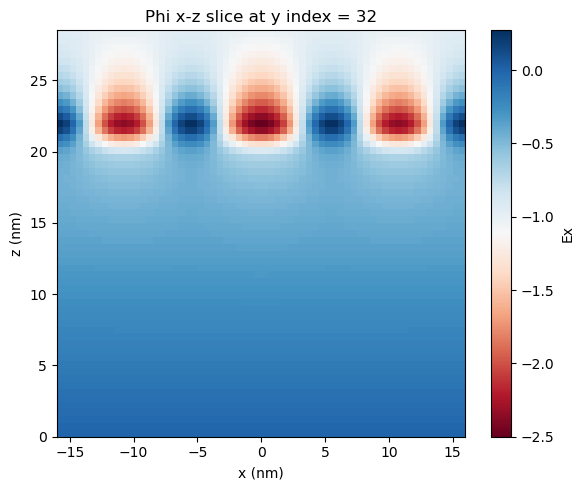

yt : [INFO     ] 2026-07-08 16:59:22,170 Parameters: current_time              = 1.1786199999985316e-08
yt : [INFO     ] 2026-07-08 16:59:22,171 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,171 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,171 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


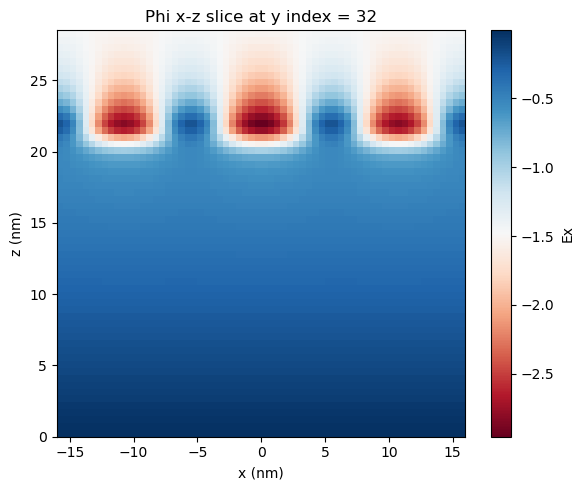

yt : [INFO     ] 2026-07-08 16:59:22,260 Parameters: current_time              = 1.2128799999984004e-08
yt : [INFO     ] 2026-07-08 16:59:22,260 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,260 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,260 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


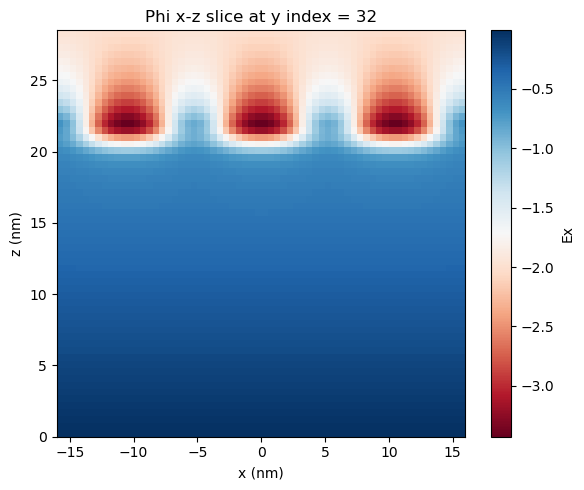

yt : [INFO     ] 2026-07-08 16:59:22,351 Parameters: current_time              = 1.2404399999982948e-08
yt : [INFO     ] 2026-07-08 16:59:22,351 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,351 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,351 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


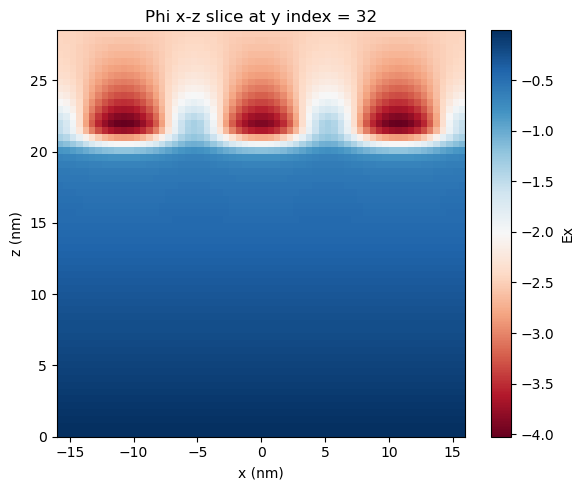

yt : [INFO     ] 2026-07-08 16:59:22,445 Parameters: current_time              = 1.285859999998121e-08
yt : [INFO     ] 2026-07-08 16:59:22,446 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,446 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,446 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


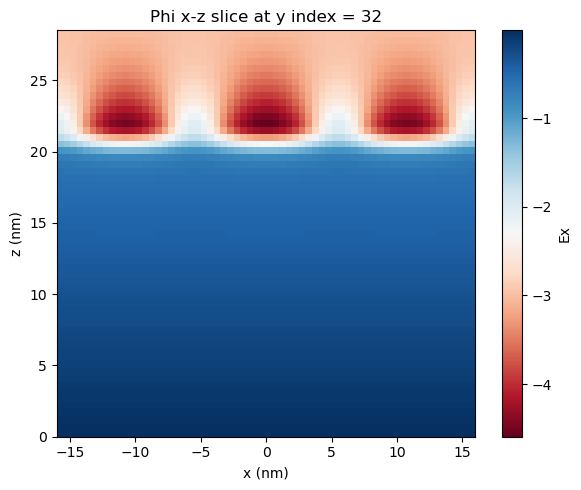

yt : [INFO     ] 2026-07-08 16:59:22,537 Parameters: current_time              = 1.3019999999980591e-08
yt : [INFO     ] 2026-07-08 16:59:22,537 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,537 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,537 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


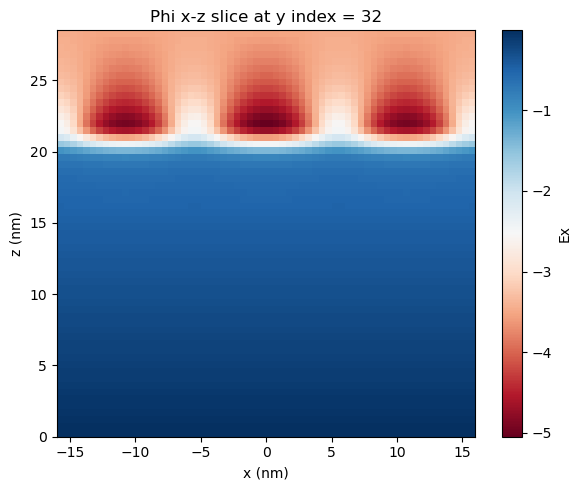

yt : [INFO     ] 2026-07-08 16:59:22,627 Parameters: current_time              = 1.3601799999978363e-08
yt : [INFO     ] 2026-07-08 16:59:22,627 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,627 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,627 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


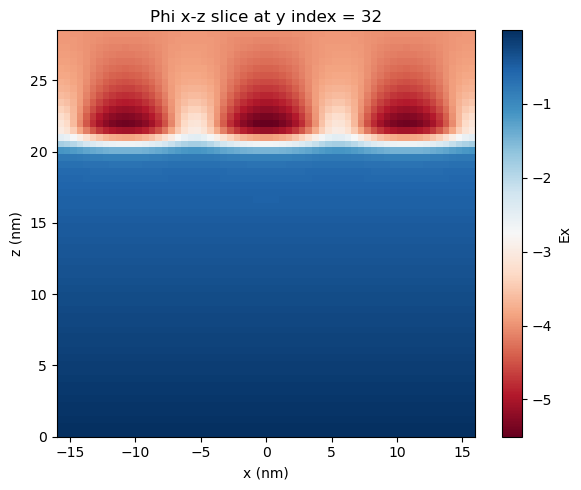

yt : [INFO     ] 2026-07-08 16:59:22,717 Parameters: current_time              = 1.3899799999977222e-08
yt : [INFO     ] 2026-07-08 16:59:22,717 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,717 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,717 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


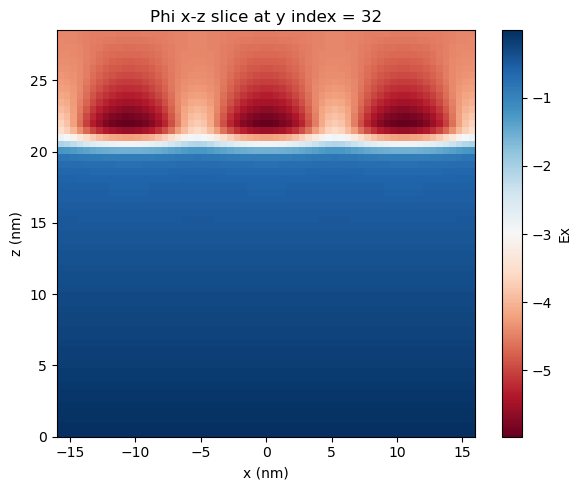

In [28]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-07-08 16:59:22,811 Parameters: current_time              = 1.240000000000013e-09
yt : [INFO     ] 2026-07-08 16:59:22,811 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:22,811 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:22,811 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


E_array shape = (64, 64, 59)


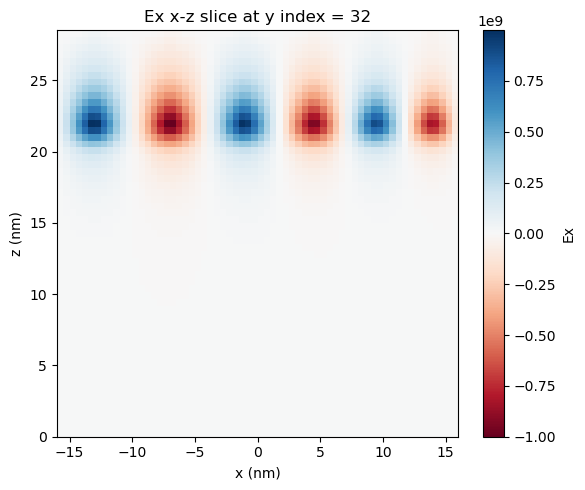

In [29]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-07-08 17:05:48,107 Parameters: current_time              = 4.396400000000981e-09
yt : [INFO     ] 2026-07-08 17:05:48,107 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:48,107 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:48,107 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


yt : [INFO     ] 2026-07-08 17:05:48,149 Parameters: current_time              = 4.610800000001047e-09
yt : [INFO     ] 2026-07-08 17:05:48,149 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:48,149 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:48,149 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:48,190 Parameters: current_time              = 4.932200000001146e-09
yt : [INFO     ] 2026-07-08 17:05:48,190 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:48,190 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:48,190 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:48,231 Parameters: current_time              = 5.034400000001177e-09
yt : [INFO     ] 2026-07-08 17:05:48,231 Parameters: domain_dimensi

Plotfiles to draw:
  plt00021982
  plt00023054
  plt00024661
  plt00025172
  plt00026485
  plt00027919
  plt00028357
  plt00029575
  plt00030520
  plt00031624
  plt00032099
  plt00033475
  plt00033987
  plt00035551
  plt00036822
  plt00038532
  plt00039455
  plt00043354
  plt00044579
  plt00045356
  plt00047924
  plt00049357
  plt00051046
  plt00052367
  plt00052814
  plt00054183
  plt00055026
  plt00056173
  plt00056634
  plt00058453
  plt00058931
  plt00060644
  plt00062022
  plt00064293
  plt00065100
  plt00068009
  plt00069499
37 number of plotfiles will be drawn after filtering.
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Select

yt : [INFO     ] 2026-07-08 17:05:48,500 Parameters: current_time              = 5.5838000000013455e-09
yt : [INFO     ] 2026-07-08 17:05:48,501 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:48,501 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:48,501 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:48,542 Parameters: current_time              = 5.671400000001372e-09
yt : [INFO     ] 2026-07-08 17:05:48,542 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:48,543 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:48,543 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:48,583 Parameters: current_time              = 5.915000000001447e-09
yt : [INFO     ] 2026-07-08 17:05:48,584 Parameters: domain_dimens

59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  

...

59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  

yt : [INFO     ] 2026-07-08 17:05:49,704 Parameters: current_time              = 1.1786199999985316e-08
yt : [INFO     ] 2026-07-08 17:05:49,704 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:49,704 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:49,704 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:49,745 Parameters: current_time              = 1.2128799999984004e-08
yt : [INFO     ] 2026-07-08 17:05:49,745 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:49,745 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:49,745 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:49,786 Parameters: current_time              = 1.2404399999982948e-08
yt : [INFO     ] 2026-07-08 17:05:49,787 Parameters: domain_dime

59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  

yt : [INFO     ] 2026-07-08 17:05:49,910 Parameters: current_time              = 1.3601799999978363e-08
yt : [INFO     ] 2026-07-08 17:05:49,910 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:49,911 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:49,911 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 17:05:49,953 Parameters: current_time              = 1.3899799999977222e-08
yt : [INFO     ] 2026-07-08 17:05:49,953 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 17:05:49,953 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 17:05:49,953 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
59
Domain size (nm): [32.  32.  28.5]
P full shape: (64, 64, 59)
dx, dy, dz nm: [0.5        0.5        0.48305085]
FE z range nm: 21.5 28.5
Selected z count: 14
Selected z min/max: 21.978813559322035 28.25847457627119
P_slice shape: (64, 14)
Drawing 2 plots after filtering.


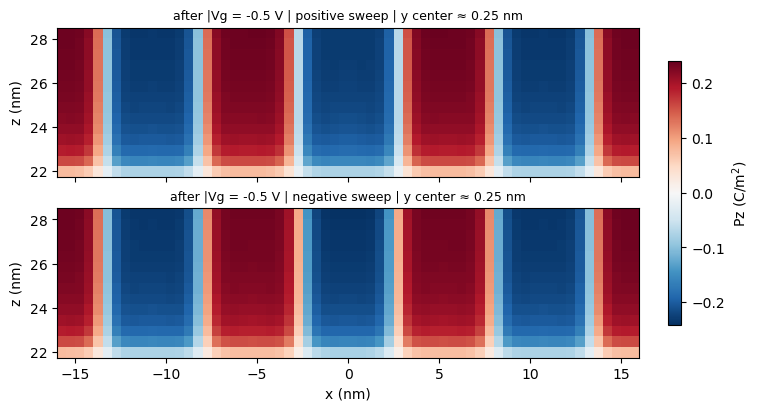

In [38]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard

SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]

#SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = False
OUT_FIG = PLOT_DIR/"Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape
    print(Nz)

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print("Domain size (nm):", (hi - lo) * 1e9)
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)
    dz_nm = dx[2] * 1e9

    print("P full shape:", P.shape)
    print("dx, dy, dz nm:", dx * 1e9)
    print("FE z range nm:", FE_Z_LO_NM, FE_Z_HI_NM)
    print("Selected z count:", np.sum(z_sel))
    print("Selected z min/max:", z_nm[z_sel].min(), z_nm[z_sel].max())
    

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]
    print("P_slice shape:", P_slice.shape)

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"after |"
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [31]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [32]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [33]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-07-08 16:59:24,984 Parameters: current_time              = 4.396400000000981e-09
yt : [INFO     ] 2026-07-08 16:59:24,984 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:24,984 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:24,985 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:25,027 Parameters: current_time              = 4.610800000001047e-09
yt : [INFO     ] 2026-07-08 16:59:25,027 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:25,027 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:25,028 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:25,070 Parameters: current_time              = 4.932200000001146e-09
yt : [INFO     ] 2026-07-08 16:59:25,070 Parameters: domain_dimensi

Finding plotfiles in plts...
['plt00021982', 'plt00023054', 'plt00024661', 'plt00025172', 'plt00026485', 'plt00027919', 'plt00028357', 'plt00029575', 'plt00030520', 'plt00031624', 'plt00032099', 'plt00033475', 'plt00033987', 'plt00035551', 'plt00036822', 'plt00038532', 'plt00039455', 'plt00043354', 'plt00044579', 'plt00045356', 'plt00047924', 'plt00049357', 'plt00051046', 'plt00052367', 'plt00052814', 'plt00054183', 'plt00055026', 'plt00056173', 'plt00056634', 'plt00058453', 'plt00058931', 'plt00060644', 'plt00062022', 'plt00064293', 'plt00065100', 'plt00068009', 'plt00069499']
Read Pz with shape (64, 64, 59) from plts/plt00021982
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00021982 | step=21982 | Vg=-4.5033 V | <Pz>_FE=+8.179414e-02
Read Pz with shape (64, 64, 59) from plts/plt00023054
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00023054 | step=23054 | Vg=-4.0020 V | <Pz>_FE=+7.2757

yt : [INFO     ] 2026-07-08 16:59:25,196 Parameters: current_time              = 5.5838000000013455e-09
yt : [INFO     ] 2026-07-08 16:59:25,196 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:25,196 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:25,197 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:25,238 Parameters: current_time              = 5.671400000001372e-09
yt : [INFO     ] 2026-07-08 16:59:25,238 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:25,238 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:25,239 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:25,280 Parameters: current_time              = 5.915000000001447e-09
yt : [INFO     ] 2026-07-08 16:59:25,280 Parameters: domain_dimens

Read Pz with shape (64, 64, 59) from plts/plt00026485
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00026485 | step=26485 | Vg=-2.4978 V | <Pz>_FE=+4.460836e-02
Read Pz with shape (64, 64, 59) from plts/plt00027919
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00027919 | step=27919 | Vg=-1.9918 V | <Pz>_FE=+2.986099e-02
Read Pz with shape (64, 64, 59) from plts/plt00028357
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00028357 | step=28357 | Vg=-1.4928 V | <Pz>_FE=+2.363539e-02
Read Pz with shape (64, 64, 59) from plts/plt00029575
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00029575 | step=29575 | Vg=-0.9888 V | <Pz>_FE=+1.200239e-02
Read Pz with shape (64, 64, 59) from plts/plt00030520
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt000305

yt : [INFO     ] 2026-07-08 16:59:25,405 Parameters: current_time              = 6.419800000001602e-09
yt : [INFO     ] 2026-07-08 16:59:25,406 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:25,406 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:25,406 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:25,447 Parameters: current_time              = 6.695000000001686e-09
yt : [INFO     ] 2026-07-08 16:59:25,447 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:25,448 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:25,448 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:25,493 Parameters: current_time              = 6.797400000001718e-09
yt : [INFO     ] 2026-07-08 16:59:25,494 Parameters: domain_dimensi

...

Read Pz with shape (64, 64, 59) from plts/plt00052367
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00052367 | step=52367 | Vg=+2.0226 V | <Pz>_FE=-3.055800e-02
Read Pz with shape (64, 64, 59) from plts/plt00052814
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00052814 | step=52814 | Vg=+1.5237 V | <Pz>_FE=-2.419855e-02
Read Pz with shape (64, 64, 59) from plts/plt00054183
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00054183 | step=54183 | Vg=+1.0197 V | <Pz>_FE=-1.242513e-02
Read Pz with shape (64, 64, 59) from plts/plt00055026
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00055026 | step=55026 | Vg=+0.5205 V | <Pz>_FE=-7.377085e-03
Read Pz with shape (64, 64, 59) from plts/plt00056173
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt000561

yt : [INFO     ] 2026-07-08 16:59:26,371 Parameters: current_time              = 1.1690599999985682e-08
yt : [INFO     ] 2026-07-08 16:59:26,371 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:26,371 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:26,371 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:26,412 Parameters: current_time              = 1.1786199999985316e-08
yt : [INFO     ] 2026-07-08 16:59:26,412 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:26,412 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:26,412 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:26,452 Parameters: current_time              = 1.2128799999984004e-08
yt : [INFO     ] 2026-07-08 16:59:26,452 Parameters: domain_dime

Read Pz with shape (64, 64, 59) from plts/plt00056634
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00056634 | step=56634 | Vg=-0.4842 V | <Pz>_FE=+1.734573e-03
Read Pz with shape (64, 64, 59) from plts/plt00058453
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00058453 | step=58453 | Vg=-0.9888 V | <Pz>_FE=+1.200239e-02
Read Pz with shape (64, 64, 59) from plts/plt00058931
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00058931 | step=58931 | Vg=-1.4876 V | <Pz>_FE=+1.758765e-02
Read Pz with shape (64, 64, 59) from plts/plt00060644
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00060644 | step=60644 | Vg=-1.9918 V | <Pz>_FE=+2.986110e-02
Read Pz with shape (64, 64, 59) from plts/plt00062022
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt000620

yt : [INFO     ] 2026-07-08 16:59:26,576 Parameters: current_time              = 1.3019999999980591e-08
yt : [INFO     ] 2026-07-08 16:59:26,576 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:26,576 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:26,576 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:26,617 Parameters: current_time              = 1.3601799999978363e-08
yt : [INFO     ] 2026-07-08 16:59:26,617 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-07-08 16:59:26,617 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-07-08 16:59:26,617 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-07-08 16:59:26,657 Parameters: current_time              = 1.3899799999977222e-08
yt : [INFO     ] 2026-07-08 16:59:26,657 Parameters: domain_dime

Read Pz with shape (64, 64, 59) from plts/plt00064293
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00064293 | step=64293 | Vg=-2.9997 V | <Pz>_FE=+5.401669e-02
Read Pz with shape (64, 64, 59) from plts/plt00065100
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00065100 | step=65100 | Vg=-3.4987 V | <Pz>_FE=+6.110791e-02
Read Pz with shape (64, 64, 59) from plts/plt00068009
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00068009 | step=68009 | Vg=-3.9976 V | <Pz>_FE=+6.955466e-02
Read Pz with shape (64, 64, 59) from plts/plt00069499
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00069499 | step=69499 | Vg=-4.5015 V | <Pz>_FE=+8.044051e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [34]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


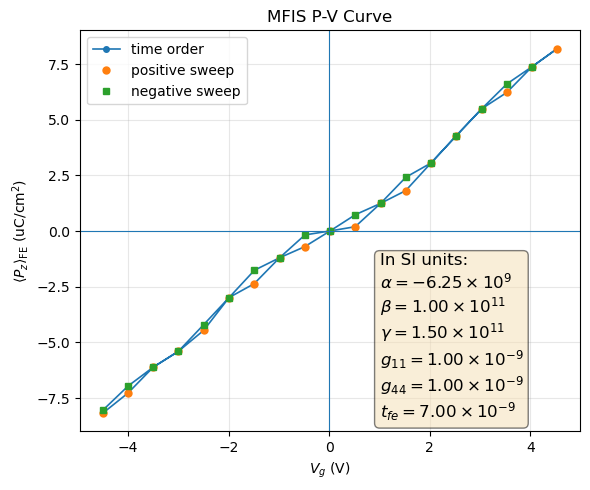

In [35]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()